<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Liz Multiple Linear Regression

Load data:

In [138]:
# Import Required Packages
import glob
import os
import zipfile
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import holidays
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn import preprocessing
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import curve_fit

In [139]:
# For use in Visual Studio

#Get all part files in order
part_files = sorted(glob.glob("data/NSW/forecastdemand_nsw.csv.zip.part*"))

# Combine them into one ZIP file
with open("data/NSW/forecastdemand_nsw.csv.zip", "wb") as output:
    for part in part_files:
        with open(part, "rb") as pf:
            output.write(pf.read())
print("Zip file reconstructed successfully")

Zip file reconstructed successfully


In [140]:
# Unzip the data files into the data folder

# List of zip files and destination folder
zip_files = [
    "data/NSW/forecastdemand_nsw.csv.zip",
    "data/NSW/temperature_nsw.csv.zip",
    "data/NSW/totaldemand_nsw.csv.zip"
]
destination_folder = "data"

# Unzip each file
for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f"Extracted: {zip_path} → {destination_folder}")
    except FileNotFoundError:
        print(f"File not found: {zip_path}")
    except zipfile.BadZipFile:
        print(f"Invalid ZIP file: {zip_path}")
    except Exception as e:
        print(f"Error extracting {zip_path}: {e}")


Extracted: data/NSW/forecastdemand_nsw.csv.zip → data
Extracted: data/NSW/temperature_nsw.csv.zip → data
Extracted: data/NSW/totaldemand_nsw.csv.zip → data


In [141]:
# Remove the ZIP file if it exists
zip_path = "data/NSW/forecastdemand_nsw.csv.zip"
try:
    os.remove(zip_path)
    print(f"Removed: {zip_path}")
except FileNotFoundError:
    print(f"File not found (skipped): {zip_path}")
except Exception as e:
    print(f"Error removing {zip_path}: {e}")

# List contents of the 'data' folder with file sizes
data_folder = "data"
try:
    print("\nContents of 'data' folder:")
    for filename in os.listdir(data_folder):
        filepath = os.path.join(data_folder, filename)
        if os.path.isfile(filepath):
            size_kb = os.path.getsize(filepath) / 1024
            print(f"{filename:<40} {size_kb:>10.2f} KB")
except Exception as e:
    print(f"Error listing files in {data_folder}: {e}")


Removed: data/NSW/forecastdemand_nsw.csv.zip

Contents of 'data' folder:
forecastdemand_nsw.csv                    722297.76 KB
temperature_nsw.csv                         6716.26 KB
totaldemand_nsw.csv                         5660.43 KB


In [142]:
# Create dataframes

df_forecast = pd.read_csv('data/forecastdemand_nsw.csv')
df_temperature = pd.read_csv('data/temperature_nsw.csv')
df_totaldemand = pd.read_csv('data/totaldemand_nsw.csv')

In [143]:
# Remove unzipped files to save space

# List of files to remove
files_to_remove = [
    "data/forecastdemand_nsw.csv",
    "data/temperature_nsw.csv",
    "data/totaldemand_nsw.csv"
]

# Remove each file if it exists
for file_path in files_to_remove:
    try:
        os.remove(file_path)
        print(f"Removed: {file_path}")
    except FileNotFoundError:
        print(f"File not found (skipped): {file_path}")
    except Exception as e:
        print(f"Error removing {file_path}: {e}")


Removed: data/forecastdemand_nsw.csv
Removed: data/temperature_nsw.csv
Removed: data/totaldemand_nsw.csv


Add additional data:

In [144]:
# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

Convert 30 minute data points into Daily data points:

In [168]:
# Convert all to pandas datetime and normalize to day-level

# Convert DATETIME column to pandas datetime
def convert_datetime(df):
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
    return df

# Apply conversion to all datasets
df_forecast = convert_datetime(df_forecast)
df_temperature = convert_datetime(df_temperature)
df_totaldemand = convert_datetime(df_totaldemand)


# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE

# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': 'mean',
    'TOTALDEMAND': 'mean'
})

# Create binary features for extreme temperature events
df_daily['extreme_hot'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['extreme_cold'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)


print(df_daily.head())




           TEMPERATURE                  FORECASTDEMAND  TOTALDEMAND  \
                   min   max       mean           mean         mean   
DATETIME                                                              
2010-01-01        22.1  28.8  25.185417    7723.688982  7801.352917   
2010-01-02        22.2  29.4  24.795833    7804.668591  8017.459792   
2010-01-03        17.9  21.5  19.462500    7491.520488  7399.899583   
2010-01-04        17.9  23.9  20.847917    8592.014274  8241.720208   
2010-01-05        15.4  27.7  22.660417    8907.999454  8827.813125   

           extreme_hot extreme_cold  
                                     
DATETIME                             
2010-01-01       False        False  
2010-01-02       False        False  
2010-01-03       False        False  
2010-01-04       False        False  
2010-01-05       False        False  


Create Model Features:

In [199]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'extreme_hot': df_daily['extreme_hot'],
    'extreme_cold': df_daily['extreme_cold']
})
# Target variable
y= df_daily['TOTALDEMAND']['mean'].values


# Rolling averages (3-day mean temperature)
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
X['temp_diff'] = X['temp_mean'] - X['temp_mean'].shift(1)
# Add day of week and month - feature engineering
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))

# Create lagged forecast demand feature
df_daily['forecast_24H'] = df_daily['FORECASTDEMAND']['mean'].shift(1)



# Add to feature matrix X
X['forecast_24H'] = df_daily['forecast_24H'].values




# One-hot encode day of week, month
X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=False)

# Feature matrix X and target y
feature_cols = ['temp_mean', 'temp_min', 'temp_max', 'temp_rolling3', 'temp_diff', 'forecast_24H', 'extreme_hot', 'extreme_cold', 'is_holiday'] + \
               [col for col in X.columns if col.startswith('dayofweek_') or col.startswith('month_')]
X = X[feature_cols].fillna(0)

# Rename day and month columns for better clarity
# Mapping dictionaries
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Rename columns
X.rename(columns={
    **{f'dayofweek_{i}': day_map[i] for i in day_map},
    **{f'month_{i}': month_map[i] for i in month_map}
}, inplace=True)

# Remove first row to account for previous 24H forecast demand 
X = X.iloc[1:].reset_index(drop=True)
y = y[1:]


print(X.head())
print(X.dtypes)

print(y[:5])

print(X['forecast_24H'].describe())
print(X['forecast_24H'].value_counts())


   temp_mean  temp_min  temp_max  temp_rolling3  temp_diff  forecast_24H  \
0  24.795833      22.2      29.4      24.990625  -0.389583   7723.688982   
1  19.462500      17.9      21.5      23.147917  -5.333333   7804.668591   
2  20.847917      17.9      23.9      21.702083   1.385417   7491.520488   
3  22.660417      15.4      27.7      20.990278   1.812500   8592.014274   
4  22.695833      20.3      25.6      22.068056   0.035417   8907.999454   

   extreme_hot  extreme_cold  is_holiday  Monday  ...  March  April    May  \
0        False         False       False   False  ...  False  False  False   
1        False         False       False   False  ...  False  False  False   
2        False         False       False    True  ...  False  False  False   
3        False         False       False   False  ...  False  False  False   
4        False         False       False   False  ...  False  False  False   

    June   July  August  September  October  November  December  
0  False

Conduct some exploratory data analysis:

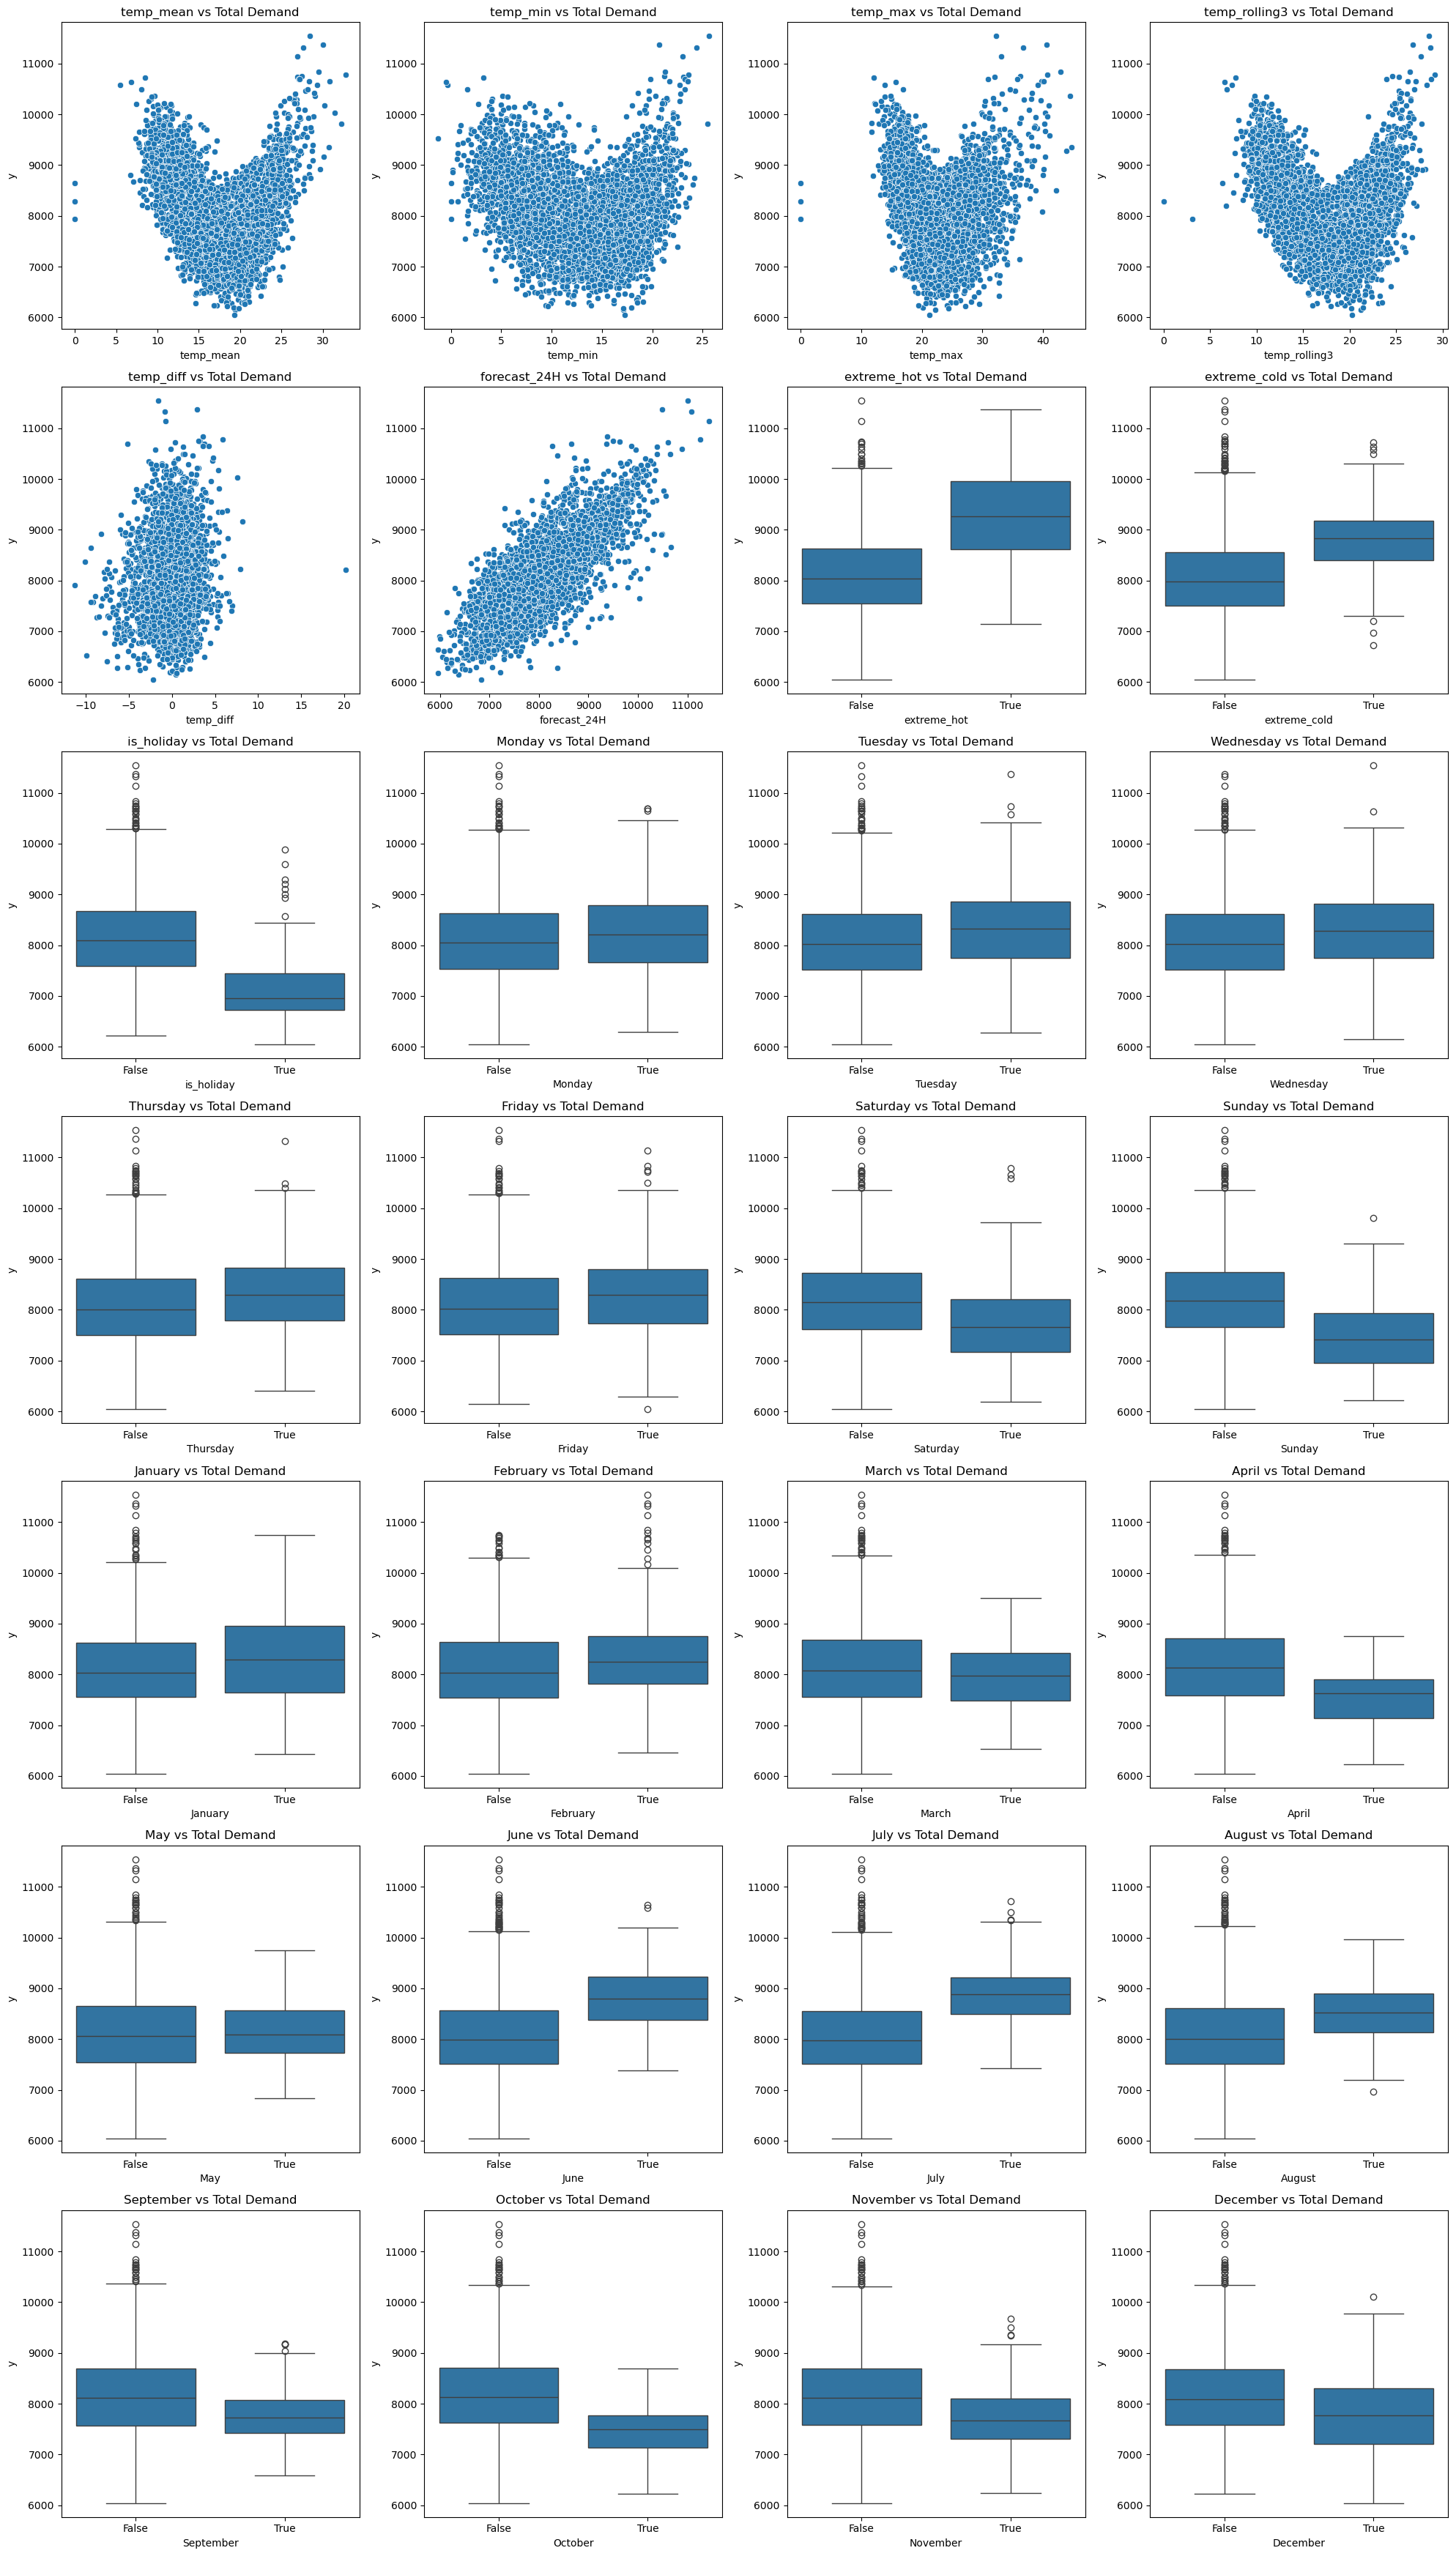

In [200]:
# Plot independent variables versus dependant variable

# Define float and boolean/categorical columns
float_cols = X.columns[:6]
bool_cols = X.columns[6:29]
all_cols = list(float_cols) + list(bool_cols)

# Total number of plots
n_plots = len(all_cols)

# Grid size
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

# Plot each feature against y
for i, col in enumerate(all_cols):
    ax = axes[i]
    if col in float_cols:
        sns.scatterplot(x=X[col], y=y, ax=ax)
    else:
        sns.boxplot(x=X[col], ax=ax, y=y)
    ax.set_title(f'{col} vs Total Demand')
    ax.set_xlabel(col)
    ax.set_ylabel('y')

# Hide unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




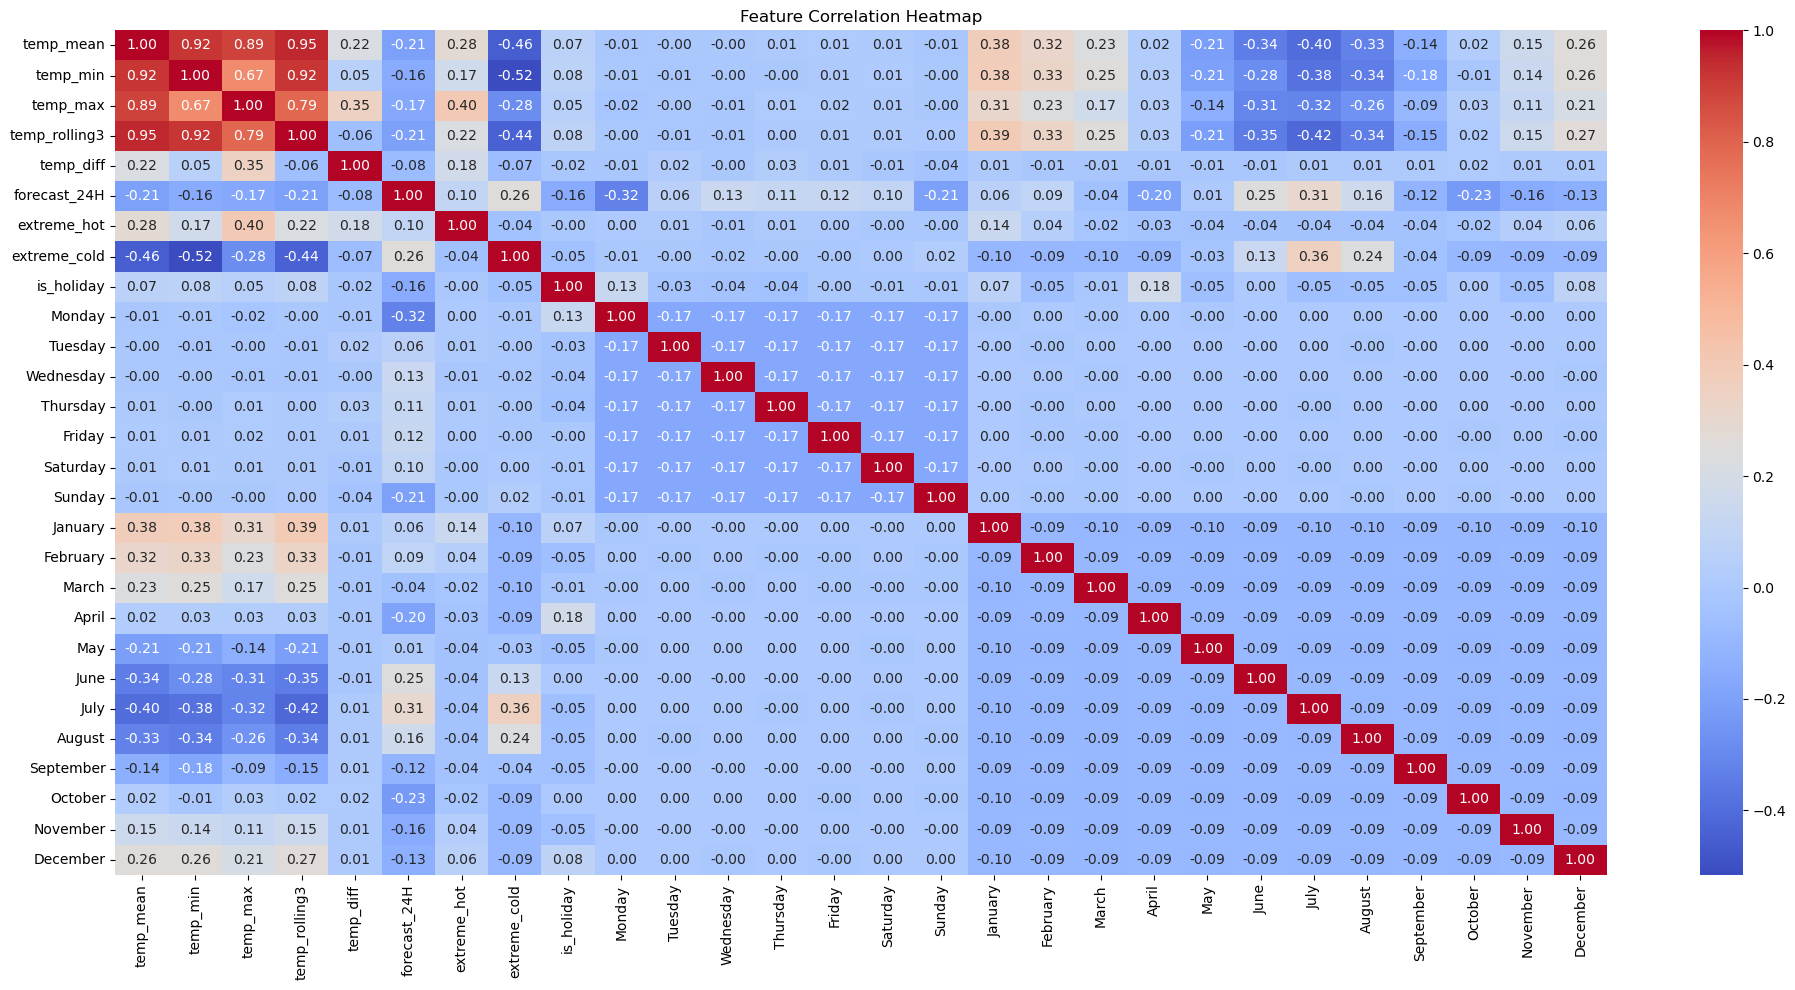

In [201]:
# Check Correlation Matrix

plt.figure(figsize=(20, 10))  
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



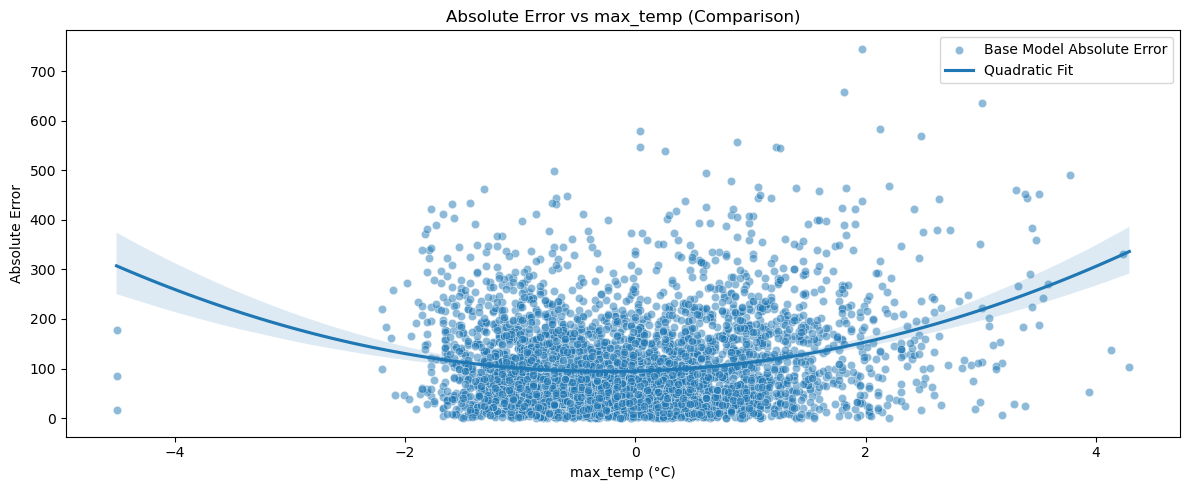

In [202]:
# Review current performance of base model "Forecast Demand"

# Absolute Error

df_daily.replace([np.inf, -np.inf], np.nan).dropna()


x = df_daily['TEMPERATURE']['max']
y_base = np.asarray(abs(df_daily['TOTALDEMAND'] - df_daily['FORECASTDEMAND'])).flatten()


# Standardize x
x_mean = x.mean()
x_std = x.std() or 1.0  # Avoid division by zero
x_scaled = (x - x_mean) / x_std
x_flat = np.asarray(x_scaled).flatten()


# Plot 
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x_flat, y=y_base, alpha=0.5, label = 'Base Model Absolute Error')
sns.regplot(x=x_flat, y=y_base, scatter=False, order=2, label = 'Quadratic Fit')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs max_temp (Comparison)")
plt.xlabel("max_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()



Mulitple Linear Regression:

In [203]:
# Create train and test dataset (70/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create linear regression model
model = LinearRegression()

# Fit the model
model.fit(X_train,y_train)

# Make predictions
y_pred = model.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred))
print(
  'R_squared : ', r2_score(y_test, y_pred))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Display
print(coef_table[['Feature', 'Coefficient']])



mean_squared_error :  93736.58112267785
mean_absolute_error :  223.03499158993176
R_squared :  0.8501289776783826
          Feature  Coefficient
0       temp_mean    35.379290
1        temp_min     3.563769
2        temp_max    -5.749087
3   temp_rolling3   -30.204181
4       temp_diff    32.091692
5    forecast_24H     0.764903
6     extreme_hot   598.266456
7    extreme_cold   149.470301
8      is_holiday  -569.808253
9          Monday   641.688760
10        Tuesday   144.236490
11      Wednesday     1.197173
12       Thursday    46.738049
13         Friday    14.729714
14       Saturday  -543.962268
15         Sunday  -304.627919
16        January    91.399138
17       February   -22.543174
18          March   -75.772947
19          April   -32.598102
20            May    32.365477
21           June   196.594392
22           July   120.478632
23         August    67.589773
24      September  -102.284221
25        October  -127.000718
26       November   -92.835434
27       December 

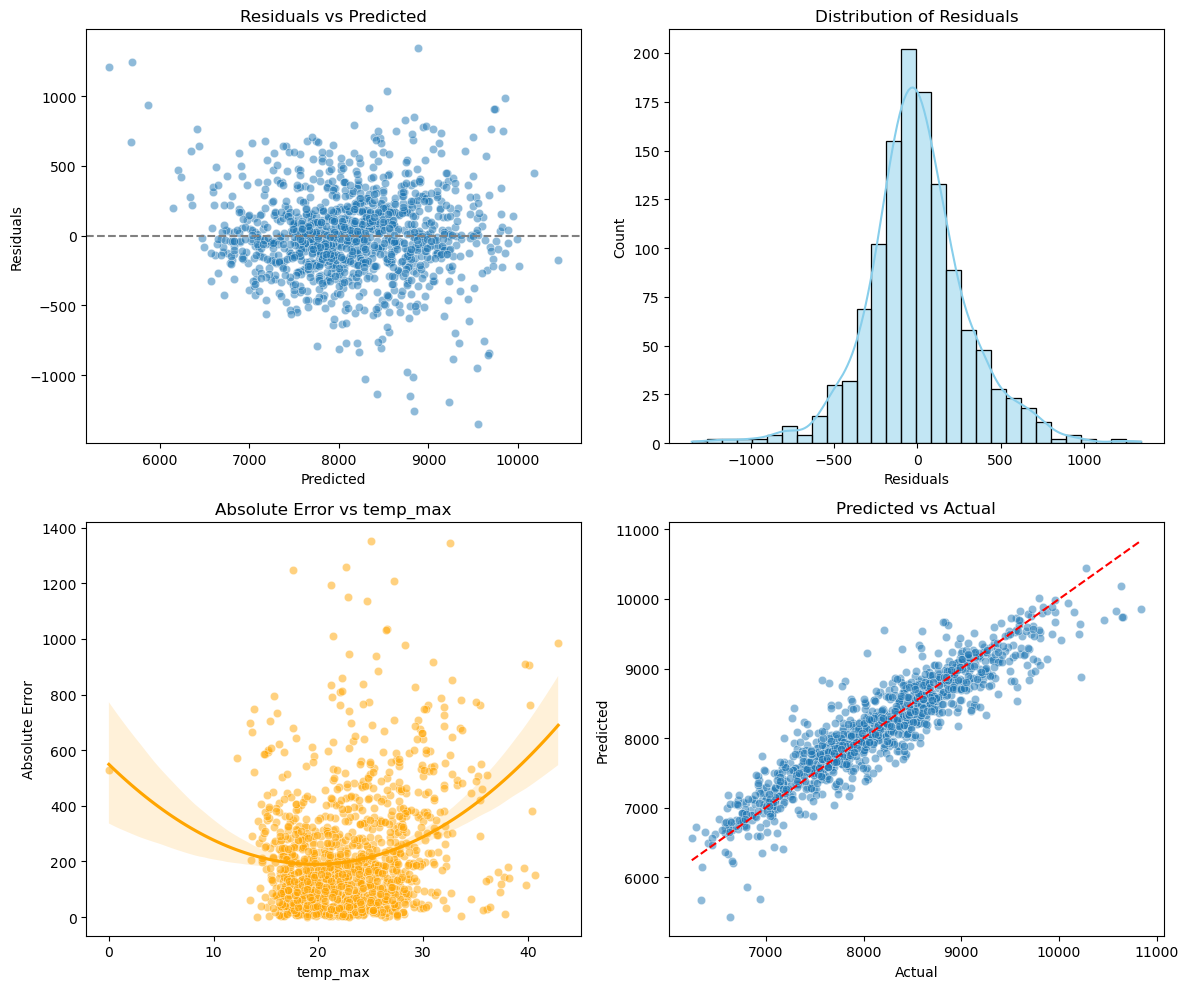

In [204]:
# Evaluation Plots

residuals = y_test - y_pred
absolute_error = np.abs(residuals)

# Create a grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Residuals')

# 2. Histogram of Residuals
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residuals')

# 3. Absolute Error vs Feature (e.g., temp_max)
sns.scatterplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 0], alpha=0.5, color='orange')
sns.regplot(x=X_test['temp_max'], y=absolute_error, ax=axes[1, 0], scatter=False, order=2, color='orange')
axes[1, 0].set_title('Absolute Error vs temp_max')
axes[1, 0].set_xlabel('temp_max')
axes[1, 0].set_ylabel('Absolute Error')

# 4. Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred, ax=axes[1, 1], alpha=0.5)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1, 1].set_title('Predicted vs Actual')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()



Multiple Linear Regression Model Using Recursive Feature Elimination:

In [205]:
# Fit RFE
rfe = RFE(model, n_features_to_select=10, step=0.5)
rfe.fit(X_train,y_train)

# Create DataFrame of rankings
rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': rfe.ranking_
}).sort_values(by='RFE_Rank')  

# Make predictions
y_pred2 = rfe.predict(X_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred2))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred2))
print(
  'R_squared : ', r2_score(y_test, y_pred2))

# Print Coefficient table

# Get selected features and their coefficients
selected_features = X.columns[rfe.support_]
selected_coefs = model.coef_[rfe.support_]


# Create a DataFrame of coefficients
coef_table2 = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': selected_coefs
})

# Display
print(coef_table2[['Feature', 'Coefficient']])


# Feature Importance 
rfe_table = rfe_df.sort_values(by='RFE_Rank')
print("\n📋 Feature Importance via RFE Ranking:\n")
print(rfe_table.to_string(index=False))


mean_squared_error :  310306.0837891703
mean_absolute_error :  440.89444626891
R_squared :  0.5038661592613902
        Feature  Coefficient
0   extreme_hot   598.266456
1  extreme_cold   149.470301
2    is_holiday  -569.808253
3      Saturday  -543.962268
4        Sunday  -304.627919
5          June   196.594392
6          July   120.478632
7     September  -102.284221
8       October  -127.000718
9      November   -92.835434

📋 Feature Importance via RFE Ranking:

      Feature  RFE_Rank
   is_holiday         1
      October         1
    September         1
       Sunday         1
         July         1
         June         1
  extreme_hot         1
 extreme_cold         1
     Saturday         1
     November         1
      January         2
      Tuesday         2
        March         2
       Monday         2
     February         3
          May         3
        April         3
       August         3
    temp_mean         3
       Friday         3
     Thursday         3
  

Polynomial Regression Model:

In [206]:
# 2nd Degree Polynomial

# Create Polynomial Features
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2_train = poly2.fit_transform(X_train)
X_poly2_test = poly2.fit_transform(X_test)
feature_names = poly2.get_feature_names_out(X_train.columns)

# Fit the model
poly2_model = model.fit(X_poly2_train, y_train)

# Make predictions
y_pred3 = poly2_model.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred3))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred3))
print(
  'R_squared : ', r2_score(y_test, y_pred3))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table3 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': poly2_model.coef_
})

# Display
print(coef_table3[['Feature', 'Coefficient']])

mean_squared_error :  51678.17892178248
mean_absolute_error :  159.24620499479232
R_squared :  0.9173741839742304
               Feature  Coefficient
0            temp_mean  -271.070122
1             temp_min    22.126000
2             temp_max   -34.349592
3        temp_rolling3   338.132300
4            temp_diff  -155.017765
..                 ...          ...
429   October November     0.000000
430   October December     0.000000
431         November^2  -442.953292
432  November December     0.000000
433         December^2  -354.056371

[434 rows x 2 columns]


In [207]:
# 3rd Degree Polynomial

# Create Polynomial Features
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3_train = poly3.fit_transform(X_train)
X_poly3_test = poly3.fit_transform(X_test)
feature_names3 = poly3.get_feature_names_out(X_train.columns)

# Fit the model
poly3_model = model.fit(X_poly3_train, y_train)

# Make predictions
y_pred4 = poly3_model.predict(X_poly3_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred4))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred4))
print(
  'R_squared : ', r2_score(y_test, y_pred4))

# Print Coefficient table
# Create a DataFrame of coefficients
coef_table4 = pd.DataFrame({
    'Feature': feature_names3,
    'Coefficient': poly3_model.coef_
})

# Display
print(coef_table4[['Feature', 'Coefficient']])

mean_squared_error :  227019.1493876059
mean_absolute_error :  230.66909276611014
R_squared :  0.6370297316393899
                  Feature  Coefficient
0               temp_mean -1646.041665
1                temp_min  -102.050475
2                temp_max   331.284532
3           temp_rolling3  1303.350498
4               temp_diff -1224.361201
...                   ...          ...
4489   October December^2     0.000000
4490           November^3 -5039.368725
4491  November^2 December     0.000000
4492  November December^2     0.000000
4493           December^3 -3317.150701

[4494 rows x 2 columns]


2nd Degree Polynomial Lasso Regression

In [208]:
# Lasso Regression Model
model2 = make_pipeline(StandardScaler(), Lasso(alpha=0.9, max_iter=100000))

# Fit the model
poly2_lasso = model2.fit(X_poly2_train, y_train)

# Make predictions
y_pred5 = poly2_lasso.predict(X_poly2_test)

# Model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, y_pred5))
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, y_pred5))
print(
  'R_squared : ', r2_score(y_test, y_pred5))

# Print Coefficient table
# Create a DataFrame of coefficients
lasso = model2.named_steps['lasso']

coef_table5 = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_,
    'Abs_Coef' : np.abs(lasso.coef_)
}).sort_values(by='Abs_Coef', ascending=False)


# Display
print(coef_table5[['Feature', 'Coefficient']])




mean_squared_error :  51219.514318261936
mean_absolute_error :  161.22387608528922
R_squared :  0.9181075212925864
                 Feature  Coefficient
5           forecast_24H   448.247362
30    temp_mean temp_max   340.601783
28           temp_mean^2   291.530127
0              temp_mean  -272.004758
158       forecast_24H^2   243.736512
..                   ...          ...
219  extreme_cold August    -0.000000
49        temp_mean June    -0.000000
216     extreme_cold May     0.000000
215   extreme_cold April     0.000000
433           December^2     0.000000

[434 rows x 2 columns]


Model Evaluation:

In [225]:
# Calculate Improvement from Base Model Performance

# Base model predictions (from df_daily)

# Align forecast demand with y_test
forecast_base = df_daily['FORECASTDEMAND']['mean'].values

print(forecast_base)

# Metrics for base forecast
mae_base = mean_absolute_error(y_base, forecast_base)
rmse_base = mean_squared_error(y_base, forecast_base, squared=False)
r2_base = r2_score(y_base, forecast_base)

# Metrics for MLR model
mae_mlr = mean_absolute_error(y_test, y_pred5)
rmse_mlr = mean_squared_error(y_test, y_pred5, squared=False)
r2_mlr = r2_score(y_test, y_pred5)

# Print comparison
print("🔍 Performance Comparison")
print(f"Base Forecast → MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}, R²: {r2_base:.4f}")
print(f"MLR Model     → MAE: {mae_mlr:.2f}, RMSE: {rmse_mlr:.2f}, R²: {r2_mlr:.4f}")


#calculate improvement
mae_improvement = mae_base - mae_mlr
rmse_improvement = rmse_base - rmse_mlr
r2_improvement = r2_mlr - r2_base
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/mae_base*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/rmse_base*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/r2_base*100:.1f}%)")

[7723.68898246 7804.66859149 7491.52048848 ... 7370.23979713 7398.57348081
 6961.07690141]
🔍 Performance Comparison
Base Forecast → MAE: 8000.26, RMSE: 8039.90, R²: -7737.5776
MLR Model     → MAE: 161.22, RMSE: 226.32, R²: 0.9181

MAE improvement: 7839.0 MW (98.0%)
RMSE improvement: 7813.6 MW (97.2%)
R² improvement: 7738.496 (-100.0%)


c:\Users\lizmu\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\lizmu\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


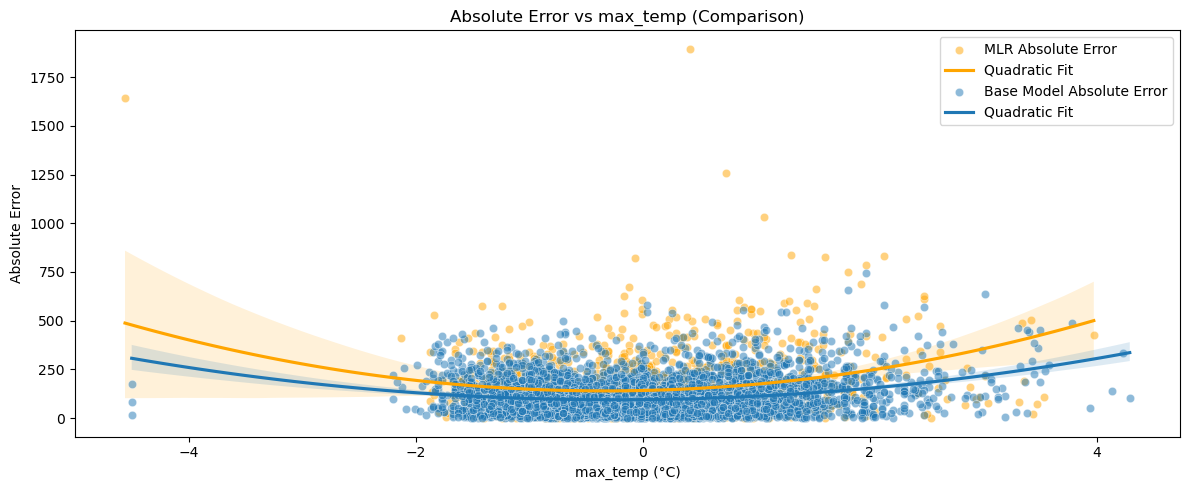

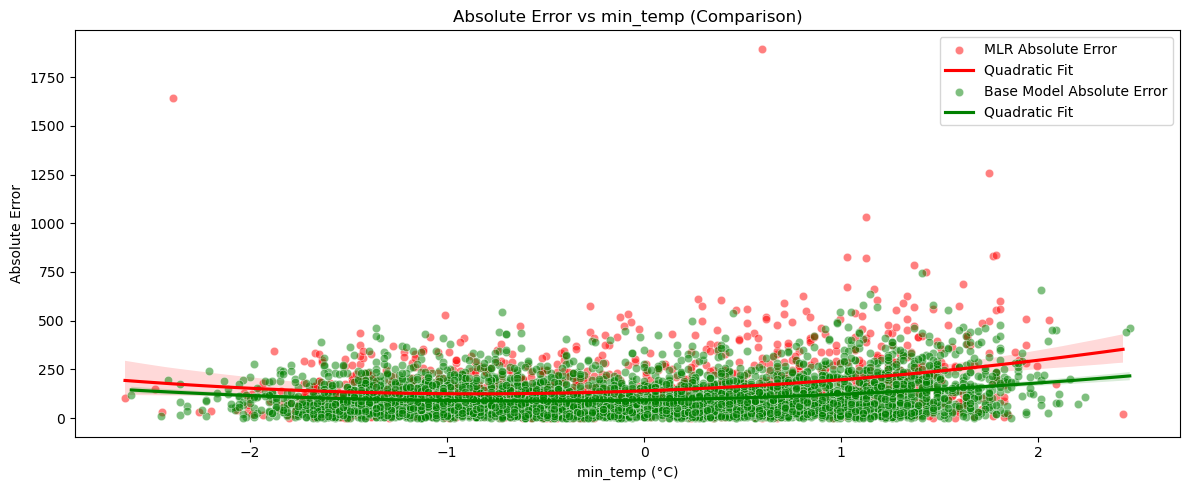

In [209]:
# Absolute Error versus Max Temp

df_daily.replace([np.inf, -np.inf], np.nan).dropna()

residuals = y_test - y_pred5
absolute_error = abs(residuals)

x1_test = pd.DataFrame(X_poly2_test, columns=feature_names, index=X_test.index)

x1_max = x1_test['temp_max']
y1 = np.asarray(absolute_error).flatten()  
x2_max = df_daily['TEMPERATURE']['max']
y2 = np.asarray(abs(df_daily['TOTALDEMAND'] - df_daily['FORECASTDEMAND'])).flatten()


# Standardize x
x1_max_mean = x1_max.mean()
x1_max_std = x1_max.std() or 1.0  # Avoid division by zero
x1_max_scaled = (x1_max - x1_max_mean) / x1_max_std
x1_max_flat = np.asarray(x1_max_scaled).flatten()

x2_max_mean = x2_max.mean()
x2_max_std = x2_max.std() or 1.0  # Avoid division by zero
x2_max_scaled = (x2_max - x2_max_mean) / x2_max_std
x2_max_flat = np.asarray(x2_max_scaled).flatten()


# Plot both datasets
plt.figure(figsize=(12, 5))

# MLR error versus temp_max
sns.scatterplot(x=x1_max_flat, y=y1, alpha=0.5, label='MLR Absolute Error', color = 'orange')
sns.regplot(x=x1_max_flat, y=y1, scatter=False, order=2, label = 'Quadratic Fit', color = 'orange')  # quadratic fit

# Forecast demand error versus temp_max
sns.scatterplot(x=x2_max_flat, y=y2, alpha=0.5, label = 'Base Model Absolute Error')
sns.regplot(x=x2_max_flat, y=y2, scatter=False, order=2, label = 'Quadratic Fit')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs max_temp (Comparison)")
plt.xlabel("max_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()



# Absolute Error versus Min Temp

df_daily.replace([np.inf, -np.inf], np.nan).dropna()

residuals = y_test - y_pred5
absolute_error = abs(residuals)

x1_test = pd.DataFrame(X_poly2_test, columns=feature_names, index=X_test.index)

x1_min = x1_test['temp_min']
y1 = np.asarray(absolute_error).flatten()
x2_min = df_daily['TEMPERATURE']['min']
y2 = np.asarray(abs(df_daily['TOTALDEMAND'] - df_daily['FORECASTDEMAND'])).flatten()

# Standardize x
x1_min_mean = x1_min.mean()
x1_min_std = x1_min.std() or 1.0  # Avoid division by zero
x1_min_scaled = (x1_min - x1_min_mean) / x1_min_std
x1_min_flat = np.asarray(x1_min_scaled).flatten()

x2_min_mean = x2_min.mean()
x2_min_std = x2_min.std() or 1.0  # Avoid division by zero
x2_min_scaled = (x2_min - x2_min_mean) / x2_min_std
x2_min_flat = np.asarray(x2_min_scaled).flatten()

# Plot both datasets
plt.figure(figsize=(12, 5))

# MLR error versus temp_min
sns.scatterplot(x=x1_min_flat, y=y1, alpha=0.5, label='MLR Absolute Error', color='red')
sns.regplot(x=x1_min_flat, y=y1, scatter=False, order=2, label='Quadratic Fit', color='red')  # quadratic fit

# Forecast demand error versus temp_min
sns.scatterplot(x=x2_min_flat, y=y2, alpha=0.5, label='Base Model Absolute Error', color='green')
sns.regplot(x=x2_min_flat, y=y2, scatter=False, order=2, label='Quadratic Fit', color='green')  # quadratic fit

# Labels and legend
plt.title("Absolute Error vs min_temp (Comparison)")
plt.xlabel("min_temp (°C)")
plt.ylabel("Absolute Error")
plt.legend()
plt.tight_layout()
plt.show()